Biometrich Technologies and Behavioural Security
# **<center>Tutorial -  CNN Keras Face Recognizer</center>**

In [ ]:
#@title Step 1: Load Data and packages
import matplotlib.pyplot as plt
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import os
import dlib
import time
from skimage import feature
from IPython.display import HTML, display
from IPython.display import clear_output

#Function for progress bar.
def progress(value, max=100):
    return HTML("""<progress value='{value}' max='{max}', style='width: 100%'>
            {value}
        </progress>""".format(value=value, max=max))

from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

#downloaded = drive.CreateFile({'id': '1nWbItUzADjC3OtN3ijph6S5PIMTYfT2H'})   # replace the id with id of file you want to access
downloaded = drive.CreateFile({'id': '1_thRCy-PP3Hxp5VeyKrso9OxANzIJWFp'})
downloaded.GetContentFile('dataset_detect_face.zip')        # replace the file name with your file
!unzip dataset_detect_face
clear_output()
print('Done! Press the Refresh button if files are not visible.')

Done! Press the Refresh button if files are not visible.


In [ ]:
#@title Step 2: Face extraction and preprocessing
face_detector = dlib.get_frontal_face_detector()
path = "/content/dataset_detect_face/"
images = os.listdir(path)

print('Extracting faces...')
out = display(progress(0, len(images)*2), display_id=True)
kk=0
t = time.time()
data = []
labels = []

for i in images:
    path = path + i
    images = os.listdir(path)
    for j in images:
        img = cv2.imread(path+"/"+j)
        detected_faces = face_detector(img,1)
        for i, face_rect in enumerate(detected_faces):
            crop_img = img[face_rect.top():face_rect.bottom(),face_rect.left():face_rect.right()]
            try:
              resized = cv2.resize(crop_img, (100,100), interpolation = cv2.INTER_AREA)
              data.append(resized)
              if os.path.basename(os.path.normpath(path)) == "Conte":
                  labels.append(0)
              elif os.path.basename(os.path.normpath(path)) == "Johnson":
                  labels.append(1)
              elif os.path.basename(os.path.normpath(path)) == "Merkel":
                  labels.append(2)
              elif os.path.basename(os.path.normpath(path)) == "Philippe":
                  labels.append(3)
            except:
              pass
        kk=kk+1
        out.update(progress(kk, len(images)*2))
    path = "/content/dataset_detect_face/"

elapsed = 'Process completed! Elapsed time: %.2f s' %(time.time() - t)
print(elapsed)

Extracting faces...


Process completed! Elapsed time: 3.79 s


In [ ]:
X = np.array(data)
Y = np.array(labels)

NameError: name 'np' is not defined

In [ ]:
#@title Step 3: Split train e test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size = 0.1)
print(np.shape(x_train))
#train and test norm
print(np.max(x_train))

x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255
min=np.min(x_train)
maxmin=np.max(x_train)-min
x_train = (x_train - min) /maxmin # min-max norm
x_test = (x_test - min) / maxmin
print(np.max(x_train))

print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')


(70, 100, 100, 3)
255
1.0
x_train shape: (70, 100, 100, 3)
70 train samples
8 test samples


In [ ]:
import keras
num_classes=4

# convert class vectors to one-hot binary class matrices
print(y_test)
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test_c = keras.utils.to_categorical(y_test, num_classes)
print(y_test_c)

[1 3 0 0 2 3 0 2]
[[0. 1. 0. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]]


In [ ]:
from keras.layers import Conv2D, MaxPooling2D
from keras import backend as K
from keras.layers import Dense, Dropout, Flatten, Activation
from keras.models import Sequential, Model, load_model, model_from_yaml

input_shape = (100, 100, 3)

# input image dimensions
img_rows, img_cols = 100, 100
#@title Step 5: Test with different layers and models
model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape=input_shape))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))
model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.5))
model.add(Flatten())
model.add(Dense(num_classes))
model.add(Activation('softmax'))

model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer='Adam',
              metrics=['accuracy'])

history=model.fit(x_train, y_train,
          batch_size=4,
          epochs=50,
          verbose=1,
          validation_data=(x_test, y_test_c))

Epoch 1/50
18/18 [==============================] - 2s 64ms/step - loss: 1.5179 - accuracy: 0.2571 - val_loss: 1.3614 - val_accuracy: 0.3750
Epoch 2/50
18/18 [==============================] - 1s 50ms/step - loss: 1.3078 - accuracy: 0.3143 - val_loss: 1.3280 - val_accuracy: 0.3750
Epoch 3/50
18/18 [==============================] - 1s 52ms/step - loss: 1.0946 - accuracy: 0.5143 - val_loss: 1.3814 - val_accuracy: 0.2500
Epoch 4/50
18/18 [==============================] - 1s 52ms/step - loss: 0.8219 - accuracy: 0.6429 - val_loss: 1.2468 - val_accuracy: 0.5000
Epoch 5/50
18/18 [==============================] - 1s 53ms/step - loss: 0.6848 - accuracy: 0.7286 - val_loss: 1.0786 - val_accuracy: 0.6250
Epoch 6/50
18/18 [==============================] - 1s 54ms/step - loss: 0.4768 - accuracy: 0.8143 - val_loss: 1.0897 - val_accuracy: 0.5000
Epoch 7/50
18/18 [==============================] - 1s 82ms/step - loss: 0.3247 - accuracy: 0.9286 - val_loss: 1.0125 - val_accuracy: 0.6250
Epoch 8/50
18

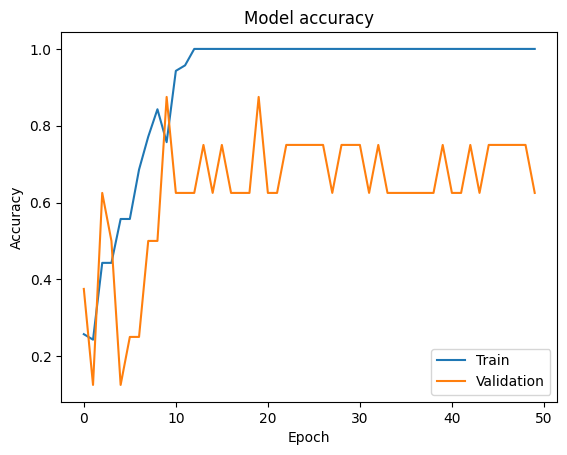

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='lower right')
plt.show()

8


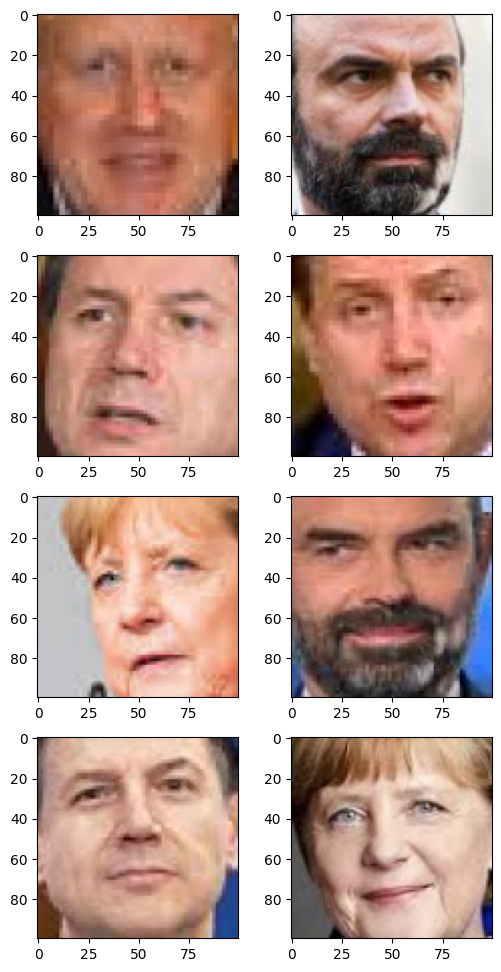

In [ ]:
#@title Step 6: Plot test samples
%matplotlib inline
xs = x_test[:]
ys = y_test_c[:]
print(len(xs))
n_cols = 2
n_rows = int(len(xs)/2)
plt.figure(figsize=(3*n_cols, 3*n_rows))
for i in range(len(xs)):
    plt.subplot(n_rows, n_cols, i+1)
    image =xs[i].reshape(100,100,3)
    im2 = image.copy()
    im2[:, :, 0] = image[:, :, 2]
    im2[:, :, 2] = image[:, :, 0]
    plt.imshow(im2)


In [ ]:
predict_x=model.predict(xs)
prediction=np.argmax(predict_x,axis=1)
print(prediction)
from sklearn.metrics import accuracy_score
acc='Total Accuracy: %.2f %%' % (accuracy_score(y_test, prediction)*100)
print(acc)


1/1 [==============================] - 0s 126ms/step
[1 3 2 1 0 3 0 2]
Total Accuracy: 62.50 %


In [ ]:
#@title Step 7: Predict Test samples
Dict = {0: 'Conte' ,1: 'Johnson', 2: 'Merkel', 3: 'Philippe'}
n = 0
print("y_pred", "  y_ts")
for i in prediction:
  print(Dict[i],Dict[np.argmax(ys[n],axis=-1)])
  n = n + 1

y_pred   y_ts
Johnson Johnson
Philippe Philippe
Merkel Conte
Johnson Conte
Conte Merkel
Philippe Philippe
Conte Conte
Merkel Merkel


In [ ]:
downloaded = drive.CreateFile({'id': '1I0B8oVrATsKE4SrdFpSYQ3kXrdiTr8kY'})
downloaded.GetContentFile('test.zip')        # replace the file name with your file
!unzip '/content/test.zip'


Archive:  /content/test.zip
  inflating: test_1.jpg              
  inflating: test_3.jpg              
  inflating: test_4.jpg              


1/1 [==============================] - 0s 24ms/step


<ipython-input-11-300b6ada6034>:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  n = int(prediction)


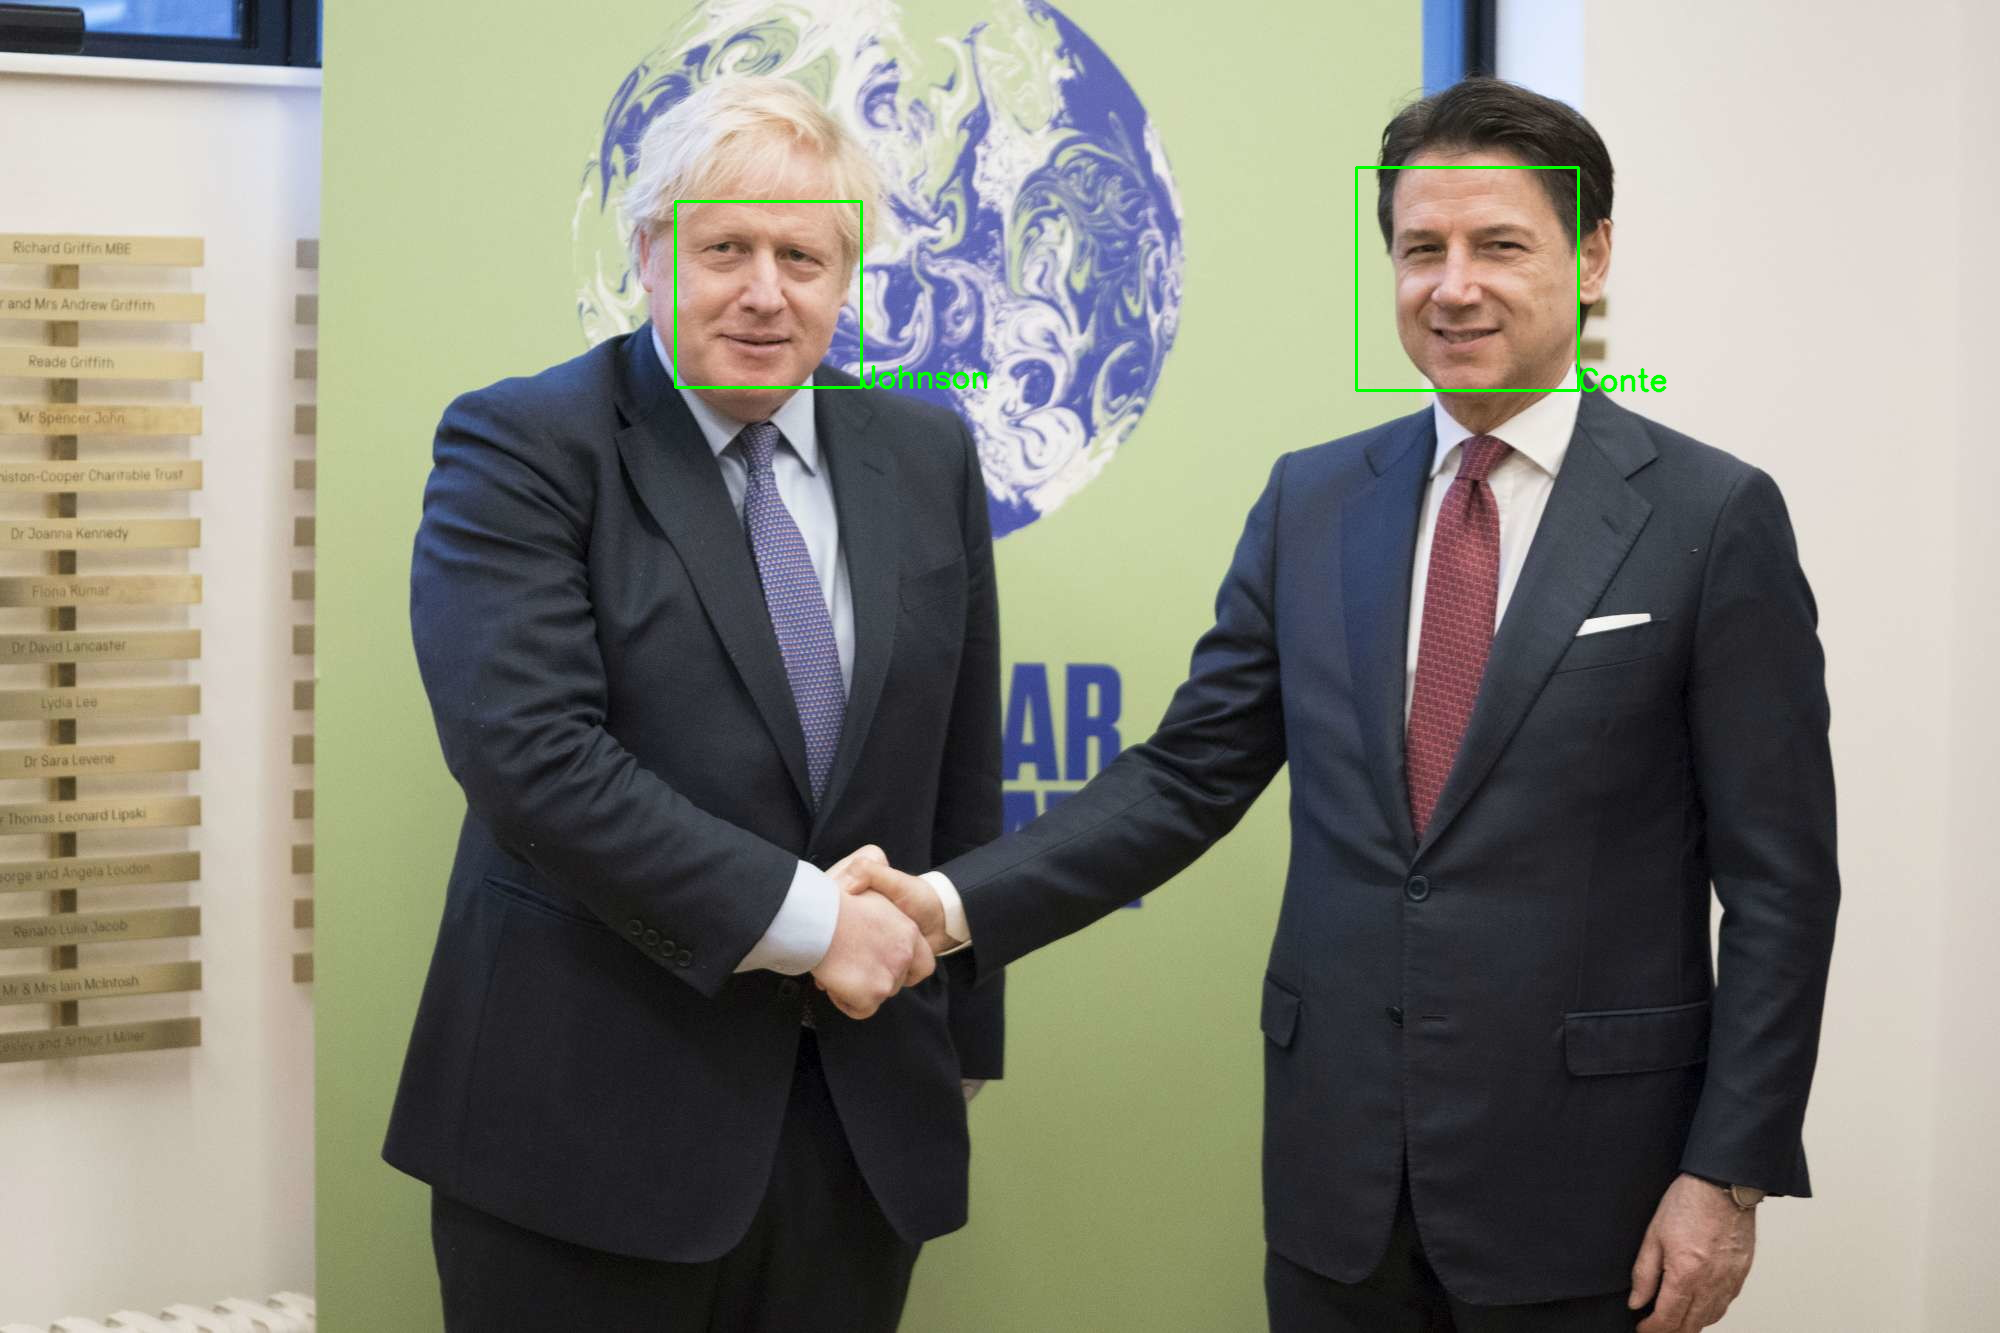

In [ ]:
#@title Step 8: Face Detection
img = cv2.imread('/content/test_1.jpg')
detected_faces = face_detector(img,1)
for i, face_rect in enumerate(detected_faces):
    width = face_rect.right() - face_rect.left()
    height = face_rect.bottom() - face_rect.top()
    crop_img = img[face_rect.top():face_rect.bottom(),face_rect.left():face_rect.right()]
    crop_img = cv2.resize(crop_img, (100,100), interpolation = cv2.INTER_AREA)
    crop_img = crop_img.astype('float32')
    crop_img /= 255
    crop_img = (crop_img - min) /maxmin
    predict_x=model.predict(crop_img.reshape(1,100,100,3))
    prediction=np.argmax(predict_x,axis=1)
    n = int(prediction)
    image = cv2.rectangle(img, (face_rect.left(), face_rect.top()), (face_rect.right(),face_rect.bottom()),(0,255,0), 2)
    image = cv2.putText(image, Dict[n], (face_rect.right(), face_rect.bottom()), cv2.FONT_HERSHEY_SIMPLEX ,
								1, (0, 255, 0), 2, cv2.LINE_AA)

cv2_imshow(image)
cv2.waitKey(0)
cv2.destroyAllWindows()